In [1]:
import pandas as pd
import numpy as np
from tslearn.datasets import UCR_UEA_datasets
import matplotlib.pyplot as plt
import seaborn as sns

# Data

In [2]:
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

# Explo

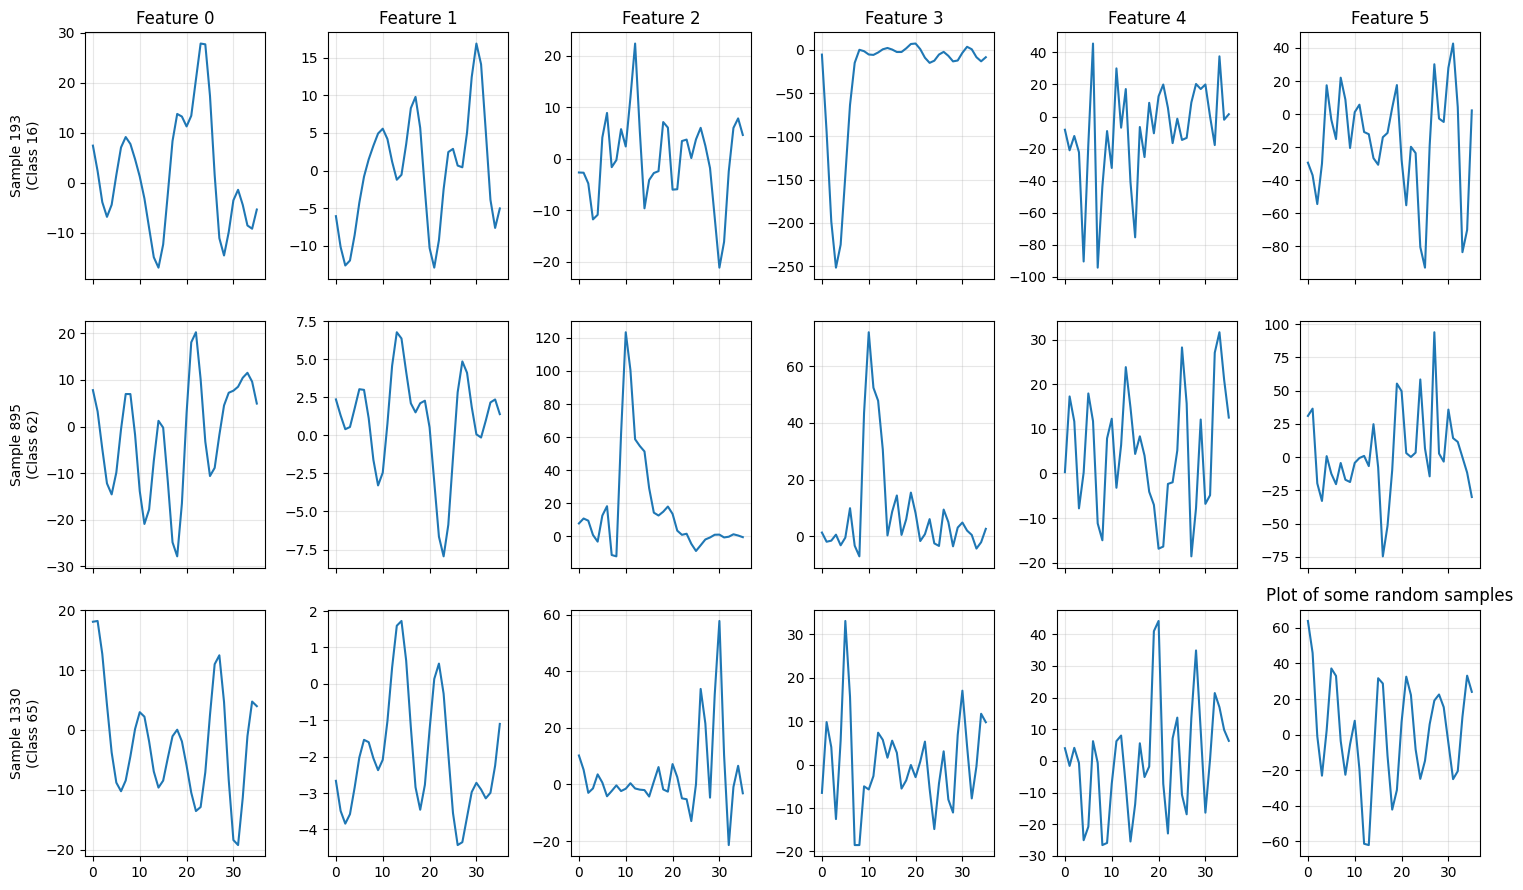

In [3]:
def plot_time_series_samples(X, y, n_samples=3):
    """
    Visualizes random samples from the dataset for each feature.
    """
    n_classes = len(np.unique(y))
    n_features = X.shape[2]
    
    fig, axes = plt.subplots(n_samples, n_features, figsize=(15, 3 * n_samples), sharex=True)
    
    indices = np.random.choice(len(X), n_samples, replace=False)
    
    for i, idx in enumerate(indices):
        for j in range(n_features):
            ax = axes[i, j]
            ax.plot(X[idx, :, j], label=f'Feature {j}')
            if i == 0:
                ax.set_title(f'Feature {j}')
            if j == 0:
                ax.set_ylabel(f'Sample {idx}\n(Class {y[idx]})')
            ax.grid(True, alpha=0.3)

    plt.title("Plot of some random samples")
    plt.tight_layout()
    plt.show()


plot_time_series_samples(X_train, y_train)

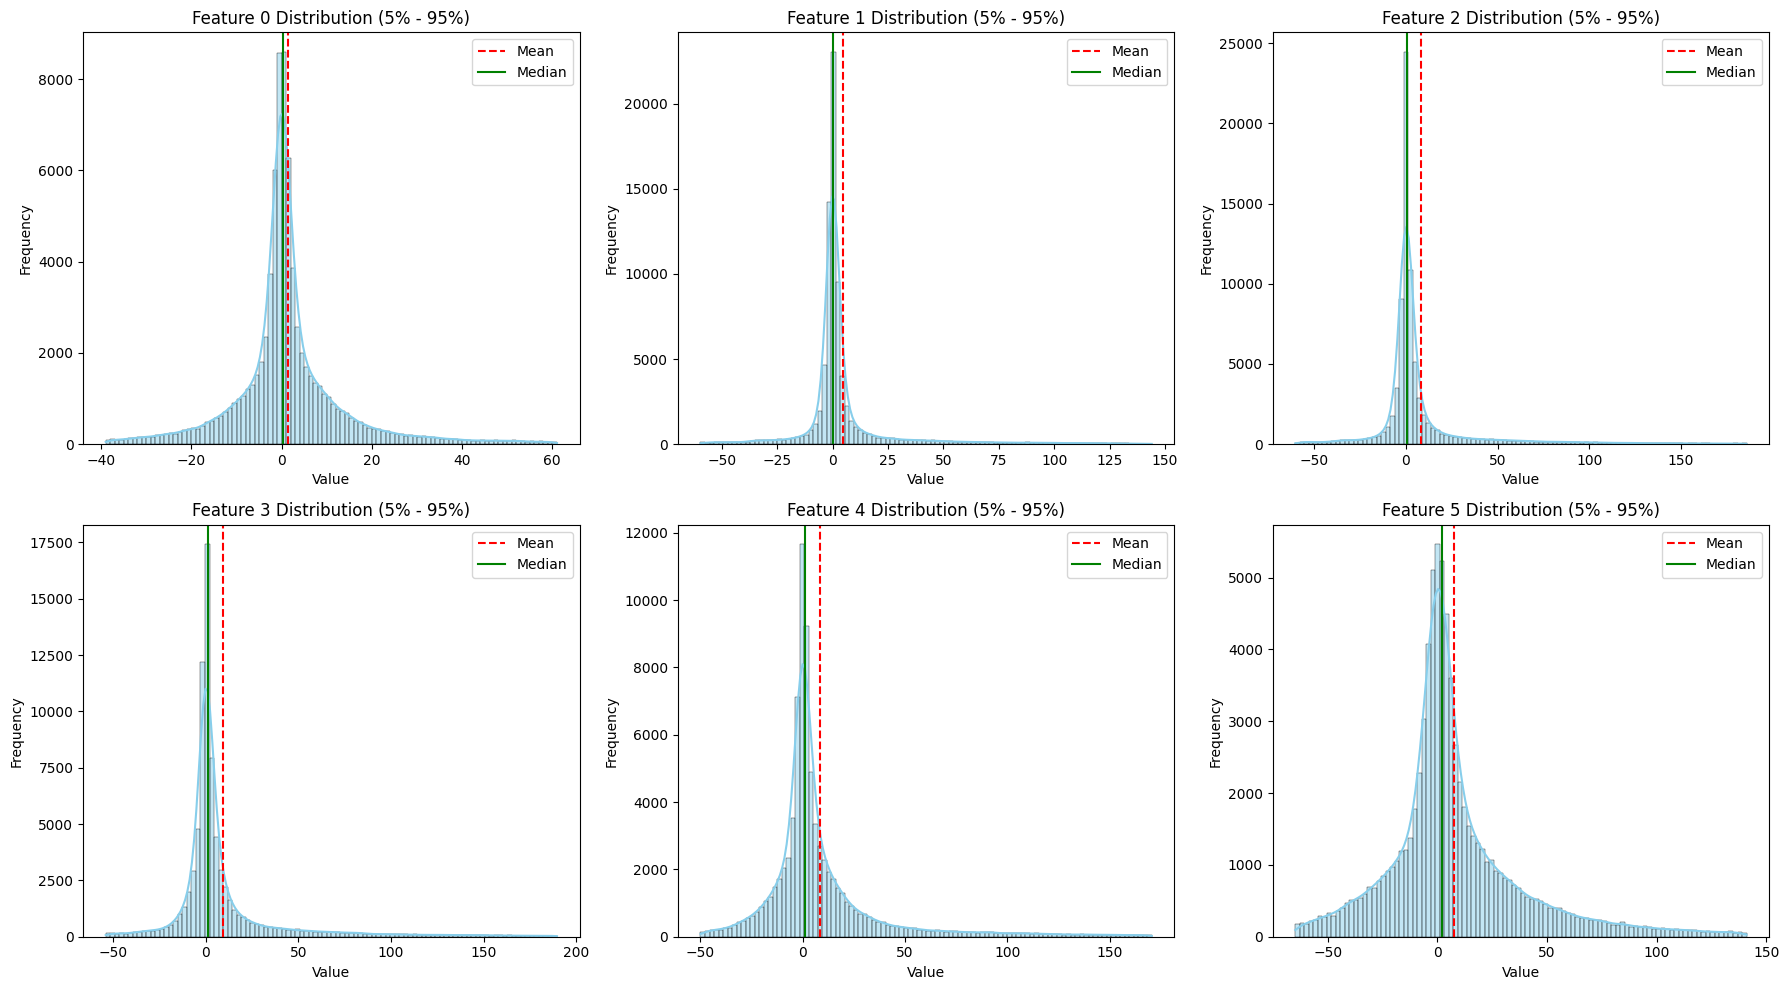

In [4]:
def plot_feature_distributions_clipped(X, epsilon):
    """
    Plots the distribution of each of the 6 features in subplots.
    Filters data to show only values between the specified quantiles.
    
    Parameters:
    X : np.array of shape (n_samples, 36, 6)
    q_low : float, lower quantile bound
    q_high : float, upper quantile bound
    """
    n_features = X.shape[2]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    q_low = epsilon
    q_high = 1 - epsilon

    for i in range(n_features):
        # Flatten time and samples for the specific feature to get global distribution
        feature_data = X[:, :, i].flatten()
        
        # Calculate quantile thresholds
        lower_bound = np.quantile(feature_data, q_low)
        upper_bound = np.quantile(feature_data, q_high)
        
        # Filter the data for visualization
        filtered_data = feature_data[(feature_data >= lower_bound) & (feature_data <= upper_bound)]
        
        # Plotting
        sns.histplot(filtered_data, kde=True, ax=axes[i], color='skyblue', bins=100)
        
        axes[i].set_title(f'Feature {i} Distribution ({int(q_low*100)}% - {int(q_high*100)}%)')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        
        # Scientific Note: Adding mean and median lines for skewness assessment
        axes[i].axvline(np.mean(filtered_data), color='red', linestyle='--', label='Mean')
        axes[i].axvline(np.median(filtered_data), color='green', linestyle='-', label='Median')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

plot_feature_distributions_clipped(X_train, epsilon = 0.05)

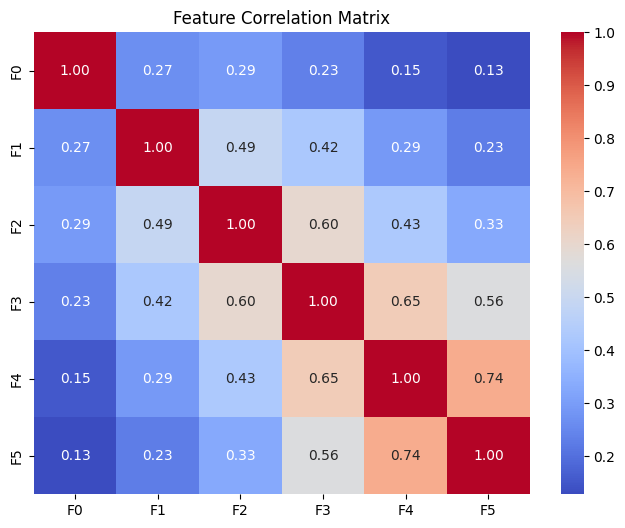

In [5]:
def plot_feature_correlation(X):
    """
    Computes correlation between the 6 features.
    """
    # Reshape to (n_samples * n_steps, n_features) to see global correlation
    flattened_data = X.reshape(-1, X.shape[2])
    df = pd.DataFrame(flattened_data, columns=[f'F{i}' for i in range(X.shape[2])])
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Feature Correlation Matrix')
    plt.show()

plot_feature_correlation(X_train)

/opt/python/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/opt/python/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/opt/python/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/opt/python/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/python/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


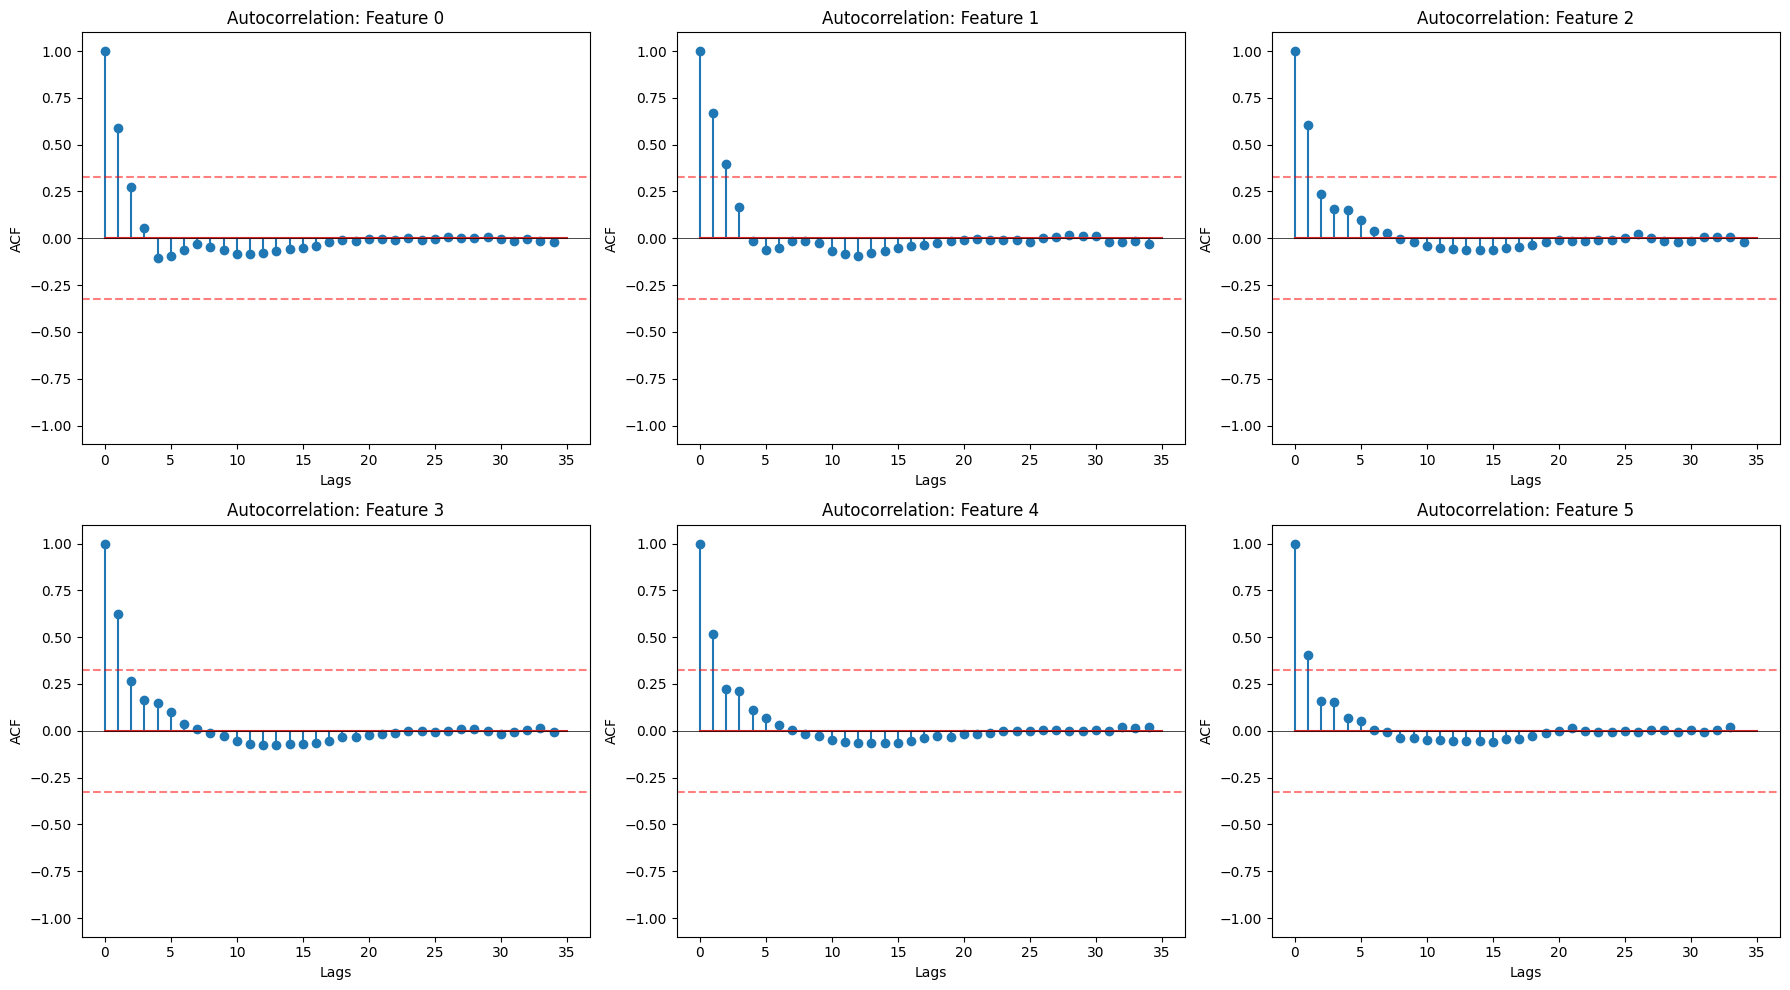

In [6]:
from statsmodels.graphics.tsaplots import plot_acf

def plot_feature_autocorrelation(X, lags=35):
    """
    Plots the autocorrelation for each of the 6 features.
    The data is averaged across all samples to find the global temporal trend per feature.
    
    Parameters:
    X : np.array of shape (n_samples, 36, 6)
    lags : int, number of lags to calculate (max is sequence_length - 1)
    """
    n_features = X.shape[2]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i in range(n_features):
        # We average the ACF across all samples to get a representative view of the feature
        # Alternatively, we could concatenate samples, but averaging ACF is more robust 
        # for identifying consistent temporal patterns.
        
        # Taking the mean signal across samples for visualization 
        # or computing mean ACF across samples:
        all_acfs = []
        for sample_idx in range(X.shape[0]):
            series = X[sample_idx, :, i]
            # Handle zero variance cases to avoid correlation errors
            if np.std(series) > 0:
                # Calculate ACF values
                corr = [np.corrcoef(series[lag:], series[:-lag])[0, 1] if lag > 0 else 1.0 
                        for lag in range(lags + 1)]
                all_acfs.append(corr)
        
        mean_acf = np.mean(all_acfs, axis=0)
        
        # Plotting manually for better control over the 6 subplots
        axes[i].stem(range(len(mean_acf)), mean_acf)
        axes[i].axhline(0, color='black', linestyle='-', linewidth=0.5)
        
        # Significance threshold (approximate 95% confidence interval)
        conf_interval = 1.96 / np.sqrt(X.shape[1])
        axes[i].axhline(conf_interval, color='red', linestyle='--', alpha=0.5)
        axes[i].axhline(-conf_interval, color='red', linestyle='--', alpha=0.5)
        
        axes[i].set_title(f'Autocorrelation: Feature {i}')
        axes[i].set_xlabel('Lags')
        axes[i].set_ylabel('ACF')
        axes[i].set_ylim([-1.1, 1.1])

    plt.tight_layout()
    plt.show()

plot_feature_autocorrelation(X_train)